# 02 · Resultados de la grilla de experimentos

Resultados de los 6 runs de la grilla (`vanilla`, `cam`, `laam`, `claam`, `msfm`, `clamf`;
[`docs/experiments.md`](../docs/experiments.md)), entrenados en RunPod y bajados con
`scripts/runpod/pull.sh` a `results/runpod/`. Todo se lee de los runs de MLflow con
`clamf.results`; ningún número se copia a mano.

- **Split: val, provisional** (D-003, D-013). Val también se usó para early stopping y selección de
  modelo, así que las cifras salen optimistas; el sesgo es parecido entre modelos. Cuando llegue el
  `y_aux` de test, basta con evaluar test (`clamf.evaluate --split test`) y cambiar `SPLIT`.
- **Métricas:** por cuenca, sobre todos los pares (ventana, hora de anticipación), y mediana/media
  sobre las 508 cuencas, excluyendo las cuencas con denominador degenerado (D-003). La versión
  literal (sin excluir) va como referencia.
- Las figuras se guardan en `reports/figures/`.

In [1]:
import os
from pathlib import Path

import pandas as pd

from clamf import plots
from clamf.results import Grid, paired_comparison

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
TRACKING_URI = os.environ.get(
    "MLFLOW_TRACKING_URI", f"sqlite:///{ROOT / 'results' / 'runpod' / 'mlflow.db'}"
)
FIGURES = ROOT / "reports" / "figures"
SPLIT = "val"  # provisional until test has y_aux (D-013)

pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)
plots.use_style()

grid = Grid.load(tracking_uri=TRACKING_URI)
grid.names

['vanilla', 'cam', 'laam', 'claam', 'msfm', 'clamf']

## 1. Runs de la grilla

Cada run es una combinación distinta de los tres flags del modelo (D-018). Todos salen del mismo
commit, sin cambios locales, con seed 2025, en un RTX 4090 con bf16. Todos terminaron por early
stopping (paciencia 20). `best_epoch` y `epochs_run` cuentan desde 0, como se registran.

In [2]:
runs = pd.DataFrame(
    {
        "run_id": {n: r.run_id for n, r in grid.runs.items()},
        "git_commit": {n: r.tags["git_commit"][:7] for n, r in grid.runs.items()},
        "git_dirty": {n: r.tags["git_dirty"] for n, r in grid.runs.items()},
        "gpu": {n: r.params["gpu"] for n, r in grid.runs.items()},
        "amp": {n: r.params["amp"] for n, r in grid.runs.items()},
        "seed": {n: r.params["seed"] for n, r in grid.runs.items()},
    }
)
grid.flags().join(runs)

,MSFM,CAM,LAAM,run_id,git_commit,git_dirty,gpu,amp,seed
run,,,,,,,,,
vanilla,False,False,False,4ad03f540501496f80f016684ae7c1b9,c0ecaa9,false,NVIDIA GeForce RTX 4090,bf16,2025
cam,False,True,False,dad17db8f30f4e1ab4a7d85637d4631d,c0ecaa9,false,NVIDIA GeForce RTX 4090,bf16,2025
laam,False,False,True,2782b06e33a54be6887b77a90968e605,c0ecaa9,false,NVIDIA GeForce RTX 4090,bf16,2025
claam,False,True,True,3983ba0f2de94794bb8a24ec6b7e4fd6,c0ecaa9,false,NVIDIA GeForce RTX 4090,bf16,2025
msfm,True,False,False,c81bc78ecc0347e1867b5c0be19cb844,c0ecaa9,false,NVIDIA GeForce RTX 4090,bf16,2025
clamf,True,True,True,bc7c7ed2eb9645189b30eb9906571553,c0ecaa9,false,NVIDIA GeForce RTX 4090,bf16,2025


In [3]:
training = grid.training()
training.style.format(
    {"best_val_loss": "{:.3f}", "epoch_time_s": "{:.1f}", "train_time_h": "{:.2f}"}
)

,best_epoch,epochs_run,best_val_loss,epoch_time_s,train_time_h,stopped_early
run,,,,,,
vanilla,26,47,19.834,30.9,0.40,True
cam,52,73,19.805,30.4,0.62,True
laam,48,69,19.290,56.7,1.09,True
claam,26,47,19.099,56.2,0.73,True
msfm,23,44,19.090,35.2,0.43,True
clamf,21,42,18.718,60.3,0.70,True


## 2. CLAMF-Former vs Transformer vanilla

La comparación principal del laboratorio. NSE y KGE: mayor es mejor; RMSE (mm/h) y TPE-2 %: menor es
mejor; BIAS: mejor cerca de 0. `n_excluded` es el número de cuencas donde la métrica no está definida
(D-003); es el mismo para todos los modelos porque depende solo de lo observado.

In [4]:
grid.paper_table("main", SPLIT)

metric                                       nse                      kge                     rmse                      tpe                      bias                   
stat                                      median   mean n_excluded median   mean n_excluded median   mean n_excluded median   mean n_excluded  median    mean n_excluded
row                 run     MSFM CAM LAAM                                                                                                                               
CLAMF-Former        clamf   ✓    ✓   ✓    0.8659 0.7493         11 0.8158 0.7358         15 0.0237 0.0409          0 0.2496 0.2989         15 -0.0527 -0.0668         15
Transformer vanilla vanilla ✗    ✗   ✗    0.8469 0.7318         11 0.8036 0.7342         15 0.0263 0.0426          0 0.2804 0.3223         15 -0.0425 -0.0415         15

## 3. Ablaciones

**Tabla 5 · MSFM × CLAAM.** CLAMF-1 es el Transformer vanilla y CLAMF-3 es CLAAM sin MSFM.

In [5]:
grid.paper_table("table5", SPLIT)

metric                           nse                      kge                     rmse                      tpe                      bias                   
stat                          median   mean n_excluded median   mean n_excluded median   mean n_excluded median   mean n_excluded  median    mean n_excluded
row     run     MSFM CAM LAAM                                                                                                                               
CLAMF-1 vanilla ✗    ✗   ✗    0.8469 0.7318         11 0.8036 0.7342         15 0.0263 0.0426          0 0.2804 0.3223         15 -0.0425 -0.0415         15
CLAMF-2 msfm    ✓    ✗   ✗    0.8641 0.7480         11 0.8447 0.7535         15 0.0248 0.0416          0 0.2361 0.2894         15 -0.0235 -0.0377         15
CLAMF-3 claam   ✗    ✓   ✓    0.8522 0.7156         11 0.8354 0.7475         15 0.0255 0.0414          0 0.2555 0.3040         15 -0.0182 -0.0107         15
CLAMF   clamf   ✓    ✓   ✓    0.8659 0.7493         11 0.8158 0.7358         15 0.0237 0.0409          0 0.2496 0.2989         15 -0.0527 -0.0668         15

**Tabla 6 · CAM × LAAM, sin MSFM.** CLAAM-1 es el mismo run que CLAMF-1 (`vanilla`) y CLAAM el mismo
que CLAMF-3 (`claam`), así que esas filas repiten números a propósito (D-018).

In [6]:
grid.paper_table("table6", SPLIT)

metric                           nse                      kge                     rmse                      tpe                      bias                   
stat                          median   mean n_excluded median   mean n_excluded median   mean n_excluded median   mean n_excluded  median    mean n_excluded
row     run     MSFM CAM LAAM                                                                                                                               
CLAAM-1 vanilla ✗    ✗   ✗    0.8469 0.7318         11 0.8036 0.7342         15 0.0263 0.0426          0 0.2804 0.3223         15 -0.0425 -0.0415         15
CLAAM-2 cam     ✗    ✓   ✗    0.8408 0.7171         11 0.8161 0.7362         15 0.0246 0.0430          0 0.2735 0.3071         15 -0.0146 -0.0029         15
CLAAM-3 laam    ✗    ✗   ✓    0.8552 0.7616         11 0.8310 0.7431         15 0.0247 0.0418          0 0.2791 0.3105         15 -0.0119 -0.0358         15
CLAAM   claam   ✗    ✓   ✓    0.8522 0.7156         11 0.8354 0.7475         15 0.0255 0.0414          0 0.2555 0.3040         15 -0.0182 -0.0107         15

**Versión literal (todas las cuencas, sin excluir).** Solo como referencia: la media del NSE y del
KGE queda dominada por las pocas cuencas casi secas de val, donde un error diminuto da un NSE de
miles negativo (D-003). La mediana casi no cambia.

In [7]:
literal = grid.summary(SPLIT, literal=True)
literal.loc[:, (["nse", "kge"], ["median", "mean"])]

metric     nse             kge       
stat    median     mean median   mean
run                                  
vanilla 0.8433  -1.5061 0.7985 0.6497
cam     0.8384  -4.0947 0.8102 0.3810
laam    0.8520   0.2884 0.8227 0.5858
claam   0.8498  -0.6299 0.8290 0.5497
msfm    0.8606 -78.0681 0.8412 0.2338
clamf   0.8637  -3.7706 0.8109 0.6248

In [8]:
basins = grid.basin_metrics(SPLIT)
worst = pd.DataFrame(
    {n: b["nse_literal"].nsmallest(3).round(1).to_dict() for n, b in basins.items()}
).rename_axis("basin_id")
worst  # most negative literal NSE per run; all of them are excluded in the main tables

,vanilla,cam,laam,claam,msfm,clamf
basin_id,,,,,,
377,-1125.4000,-2393.2000,-220.4000,-660.3000,-40012.3000,-2286.0000
201,-6.7000,NaN,NaN,NaN,NaN,NaN
404,-4.5000,-12.7000,-11.1000,NaN,-12.8000,-7.4000
165,NaN,-11.9000,NaN,NaN,NaN,NaN
323,NaN,NaN,-2.9000,NaN,NaN,-3.6000
502,NaN,NaN,NaN,-9.3000,-7.3000,NaN
196,NaN,NaN,NaN,-6.5000,NaN,NaN


## 4. ¿Las diferencias son reales?

Las medianas de la Tabla 5 y la Tabla 6 difieren en centésimas. Para ver si una diferencia es
sistemática, se compara cada par de modelos **cuenca por cuenca** (`clamf.results.paired_comparison`):
mejora del primero sobre el segundo (positiva = el primero es mejor; en BIAS, por valor absoluto),
mediana y media, fracción de
cuencas donde gana el primero y p-value de Wilcoxon (pareado, dos colas). Hay un solo seed por modelo,
así que el test mide la consistencia entre cuencas, no la variabilidad entre entrenamientos.

In [9]:
PAIRS = [
    ("clamf", "vanilla"),  # main comparison
    ("msfm", "vanilla"),  # Table 5: MSFM alone
    ("claam", "vanilla"),  # Table 5/6: CLAAM alone
    ("clamf", "msfm"),  # CLAAM on top of MSFM
    ("clamf", "claam"),  # MSFM on top of CLAAM
    ("cam", "vanilla"),  # Table 6: CAM alone
    ("laam", "vanilla"),  # Table 6: LAAM alone
    ("claam", "cam"),  # LAAM on top of CAM
    ("claam", "laam"),  # CAM on top of LAAM
]
pd.concat(
    {m: paired_comparison(basins, PAIRS, m) for m in ("nse", "kge", "rmse", "tpe")},
    names=["metric"],
).style.format(
    {
        "median_improvement": "{:+.4f}",
        "mean_improvement": "{:+.4f}",
        "win_rate": "{:.1%}",
        "p_value": "{:.2g}",
    }
)

## 5. Distribución por cuenca

Una caja por modelo sobre las cuencas donde la métrica está definida (bigotes de 1.5 × IQR). Los
outliers no se dibujan, para que se lean las cajas; las tablas de arriba usan todos los valores.

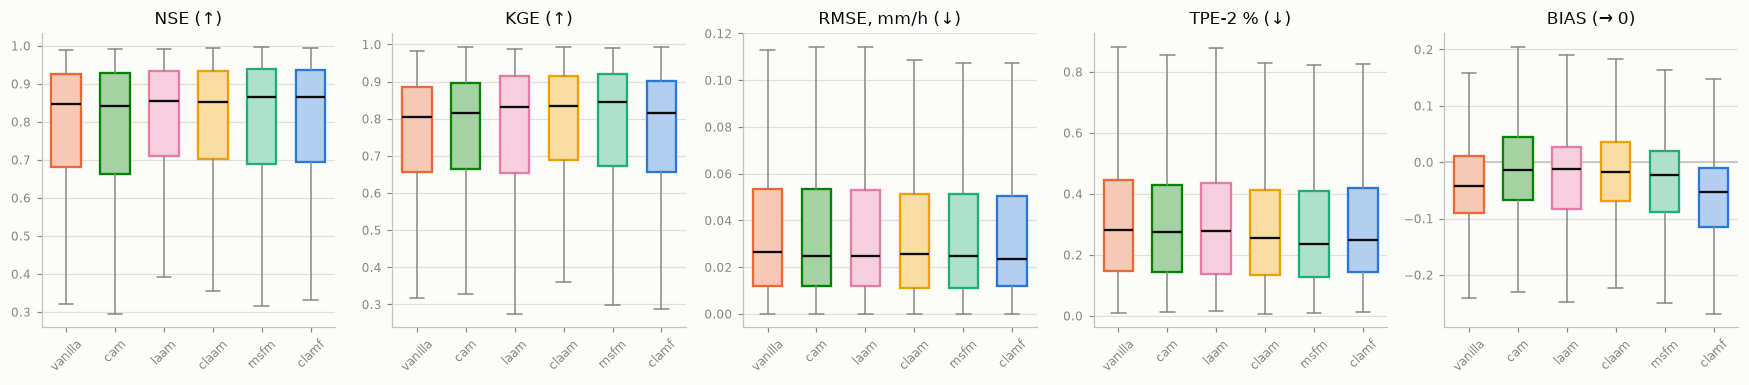

In [10]:
fig = plots.metric_boxplots(basins)
plots.save(fig, "boxplots_metrics", FIGURES);

## 6. Horizonte de predicción

NSE mediano sobre las cuencas por hora de anticipación (métrica secundaria de D-003), y su diferencia
con el Transformer vanilla.

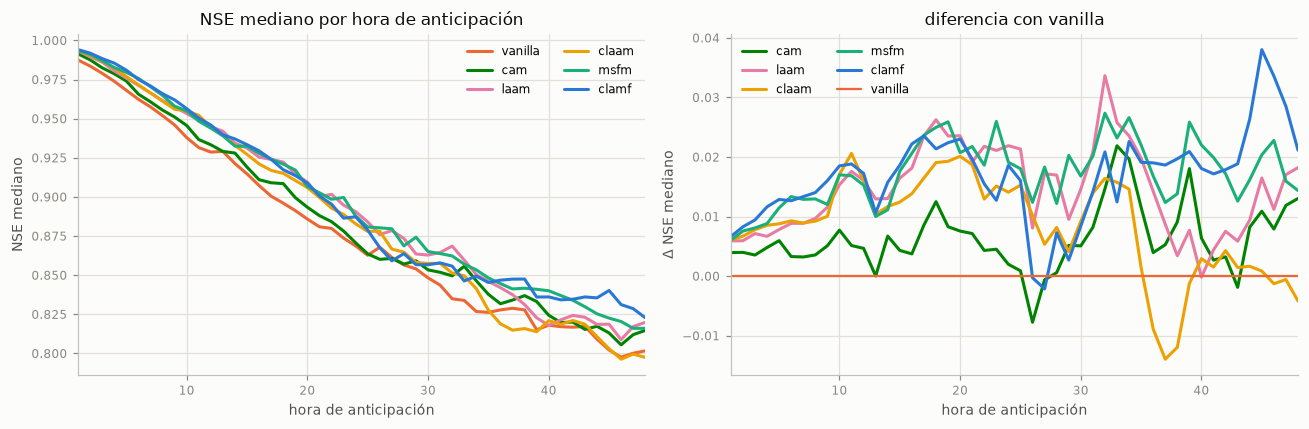

In [11]:
leads = grid.lead_metrics(SPLIT)
fig = plots.lead_curves(leads, "nse_median")
plots.save(fig, "lead_nse", FIGURES);

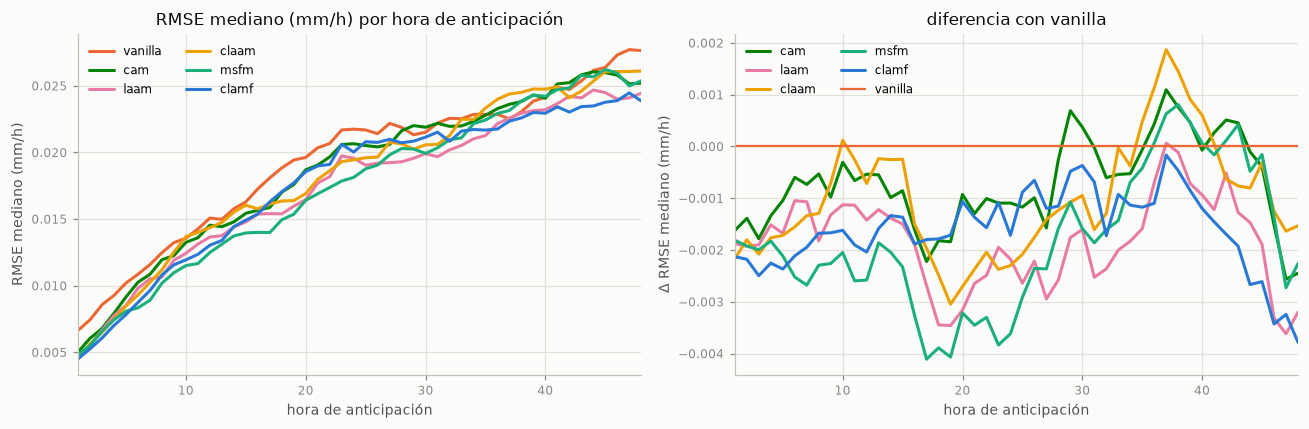

In [12]:
fig = plots.lead_curves(leads, "rmse_median")
plots.save(fig, "lead_rmse", FIGURES);

In [13]:
pd.DataFrame({n: l.loc[[1, 6, 12, 24, 36, 48], "nse_median"] for n, l in leads.items()})

,vanilla,cam,laam,claam,msfm,clamf
lead,,,,,,
1,0.9875,0.9914,0.9934,0.9935,0.9935,0.9941
6,0.9624,0.9656,0.9712,0.9716,0.9757,0.9750
12,0.9286,0.9333,0.9447,0.9447,0.9439,0.9459
24,0.8687,0.8707,0.8906,0.8828,0.8878,0.8873
36,0.8278,0.8317,0.8420,0.8189,0.8446,0.8468
48,0.8016,0.8147,0.8198,0.7974,0.8160,0.8228


## 7. Curvas de entrenamiento

FreqMAE en espacio normalizado por cuenca (D-008), por epoch. El punto marca el mejor epoch en val, el
checkpoint que se evalúa; el entrenamiento sigue 20 epochs más hasta el early stopping.

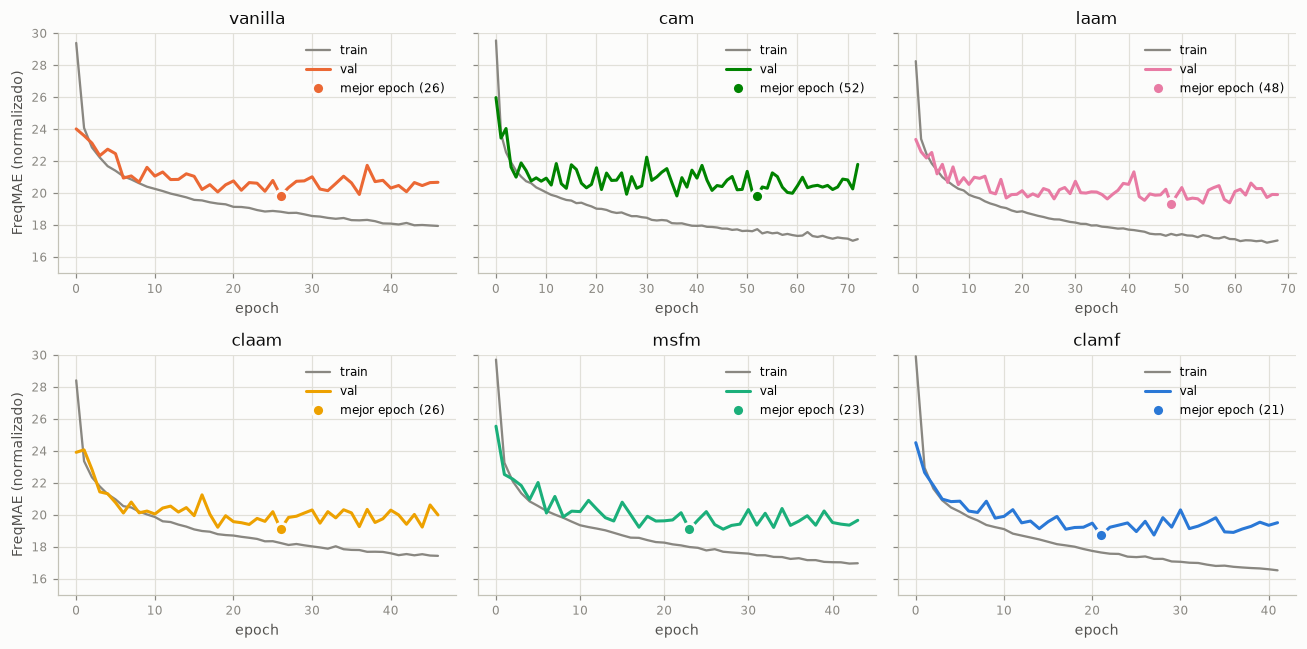

In [14]:
best = training["best_epoch"].to_dict()
fig = plots.training_curves(
    grid.history("loss/train"), grid.history("loss/val"), best, ylim=(15, 30)
)
plots.save(fig, "training_curves", FIGURES);

## 8. El desfase aprendido τ del LAAM

`τ_i` es cuántas horas hacia adelante puede mirar la posición `i` del decoder en la salida del encoder
(Eq. 4–5, D-001, D-009). Arranca cerca de 0 (atención causal). Si crece hasta cubrir el horizonte,
esa capa se comporta como una cross-attention estándar. Estadísticos sobre todo val y todas las
posiciones, en el mejor epoch.

In [15]:
grid.tau()

mean     p50     p90     max
run   layer                                
laam  all   10.3813  2.2518 41.5000 47.7500
      0      2.3500  1.5632  6.0648 12.5000
      1      7.1911  7.5318 14.8125 19.0000
      2     31.9836 40.0000 44.2500 47.7500
      3      0.0003  0.0000  0.0000  4.7586
claam all    5.2434  0.0000 20.7500 33.2500
      0      0.0154  0.0000  0.0000  4.3258
      1      4.0176  0.0541 14.5000 33.2500
      2     16.9406 20.5000 21.2500 23.5000
      3      0.0000  0.0000  0.0000  0.6060
clamf all    0.8944  0.0001  1.7270 35.2500
      0      3.2517  0.1903 12.1250 35.2500
      1      0.1304  0.0000  0.0046  6.0648
      2      0.1957  0.0001  1.1636  2.4639
      3      0.0000  0.0000  0.0000  0.0000

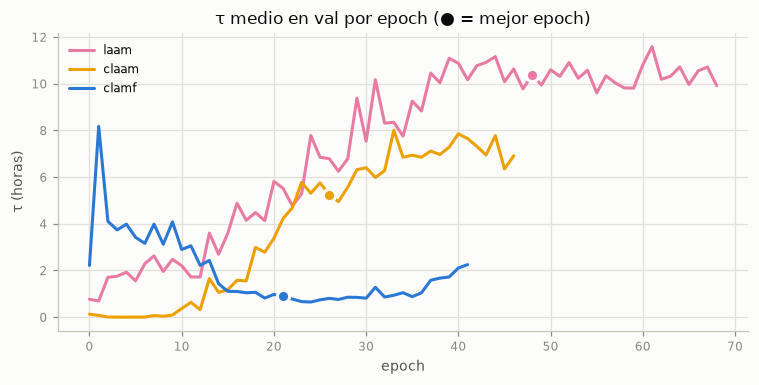

In [16]:
fig = plots.tau_curves(grid.history("tau/mean"), best)
plots.save(fig, "tau_mean", FIGURES);

## 9. Predicción vs observado

Horizonte de 48 h de algunas ventanas de val, con CLAMF-Former y el Transformer vanilla. Arriba, la
ventana con el mayor pico observado de tres cuencas representativas (percentiles 90, 50 y 25 del NSE de
CLAMF-Former). Abajo, las tres ventanas con mayor pico observado de todo val.

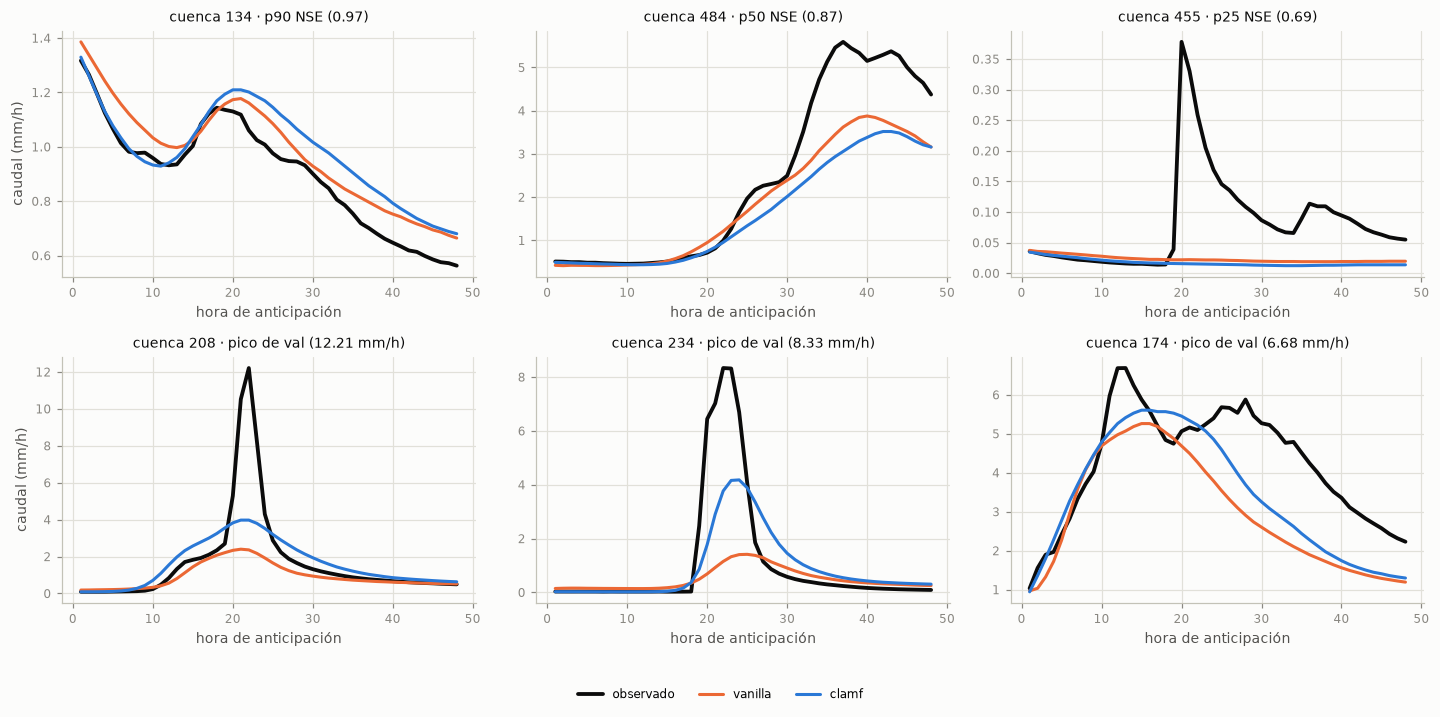

In [17]:
preds = {n: grid.predictions(n, SPLIT) for n in ("clamf", "vanilla")}
nse_clamf = basins["clamf"]["nse"].dropna().sort_values()
obs = preds["clamf"]


def peak_window(frame: pd.DataFrame) -> int:
    return int(frame.loc[frame["obs"].idxmax(), "row_id"])


row_ids, titles = [], []
for q in (0.9, 0.5, 0.25):
    basin = int(nse_clamf.index[round(q * (len(nse_clamf) - 1))])
    row_ids.append(peak_window(obs[obs["basin_id"] == basin]))
    titles.append(f"cuenca {basin} · p{int(q * 100)} NSE ({nse_clamf[basin]:.2f})")
peaks = obs.groupby("row_id")["obs"].max().nlargest(3)
for row_id in peaks.index:
    row_ids.append(int(row_id))
    basin = int(obs.loc[obs["row_id"] == row_id, "basin_id"].iloc[0])
    titles.append(f"cuenca {basin} · pico de val ({peaks[row_id]:.2f} mm/h)")

fig = plots.hydrographs(preds, row_ids, titles)
plots.save(fig, "hydrographs", FIGURES);

**Predicciones negativas.** El modelo no restringe el signo de la salida. Fracción de predicciones
negativas y su valor mínimo, por run:

In [18]:
negatives = {}
for name in grid.names:
    p = grid.predictions(name, SPLIT)["pred"]
    negatives[name] = {"fraction": (p < 0).mean(), "min_mm_h": p.min()}
pd.DataFrame(negatives).T.style.format({"fraction": "{:.2%}", "min_mm_h": "{:.4f}"})

,fraction,min_mm_h
vanilla,4.10%,-0.0058
cam,0.05%,-0.0019
laam,0.66%,-0.0028
claam,1.15%,-0.0047
msfm,8.25%,-0.0051
clamf,3.65%,-0.0060


## 10. Hallazgos

Todo sobre **val, provisional** (D-003, D-013) y con **un solo seed por modelo**.

**CLAMF-Former vs Transformer vanilla**
- CLAMF-Former es mejor en NSE (mediana 0.866 frente a 0.847), RMSE y TPE-2 %, y la mejora es
  consistente: gana en ~61 % de las cuencas en NSE y RMSE, con p < 10⁻⁴ en NSE, RMSE y TPE.
- En KGE la mejora no es significativa (p ≈ 0.23): CLAMF-Former subestima más el volumen (BIAS
  mediano −0.053 frente a −0.043), y el KGE penaliza ese sesgo.

**Tabla 5 · MSFM × CLAAM**
- Casi toda la ganancia viene del **MSFM**. `msfm` mejora a `vanilla` en todas las métricas
  (p < 10⁻⁴), y `clamf` no se distingue de `msfm` en NSE, RMSE ni TPE (p ≥ 0.07). En KGE, `clamf`
  queda incluso por debajo de `msfm` (p < 10⁻⁴), por el sesgo de volumen.
- CLAAM sin MSFM (`claam`) también mejora a `vanilla`, pero menos en NSE (p ≈ 0.004); la mejora es
  más clara en KGE y TPE.
- Salvedad (D-005): el MSFM es no causal y ve horas posteriores dentro de la ventana de entrada.
  Parte de su ventaja puede venir de ahí y no solo de las escalas gruesas.

**Tabla 6 · CAM × LAAM**
- **CAM solo** no mejora el NSE ni el RMSE (p ≥ 0.24); sí el KGE y el TPE.
- **LAAM solo** mejora el NSE (p ≈ 0.02) y el RMSE (p ≈ 0.003).
- **CLAAM** (ambos) tiene el mejor KGE de la tabla, pero su NSE no supera a `laam` (p ≈ 0.33). El
  paper reporta que CAM y LAAM se complementan; aquí eso solo aparece en KGE y TPE.

**Horizonte**
- Todos los modelos pierden precisión con la anticipación: el NSE mediano baja de ~0.99 en la
  hora 1 a ~0.80–0.82 en la hora 48.
- La ventaja sobre `vanilla` es de ~0.01–0.02 de NSE en casi todo el horizonte. `claam` queda al
  nivel de `vanilla`, o por debajo, desde la hora ~35.

**El desfase τ del LAAM**
- En `laam` y `claam`, `τ` crece durante el entrenamiento (media de 10 h y 5 h en el mejor
  epoch), concentrado en la capa 2 (32 h y 17 h de media). Esa capa ve casi todo el horizonte, así
  que se comporta como una cross-attention estándar.
- En `clamf`, `τ` se queda en ~0.9 h de media y la última capa en 0: el LAAM funciona casi como una
  atención causal. Una lectura posible es que, con el MSFM ya mezclando información hacia adelante,
  el modelo no necesita ampliar la ventana. Es coherente con que CLAAM no aporte sobre el MSFM.

**Picos y sesgos**
- Los modelos suavizan y subestiman los picos rápidos: el TPE-2 % mediano es ~0.25, un error
  relativo del 25 % en el 2 % de horas de mayor caudal. En las ventanas mostradas, CLAMF-Former se
  acerca más al pico que `vanilla`.
- Hay predicciones negativas (hasta el 8 % en `msfm`), pero ninguna baja de −0.006 mm/h: su efecto
  en las métricas es despreciable.

**Entrenamiento y métricas**
- Todos los runs alcanzan su mejor val entre los epochs 21 y 52. Después, val oscila mientras
  train sigue bajando: un sobreajuste leve que el early stopping corta.
- El LAAM casi duplica el tiempo por epoch (~56–60 s frente a ~31 s).
- La media literal del NSE está dominada por la cuenca 377 (NSE de −40 012 en `msfm`). Esto
  confirma que las tablas deben usar la versión con exclusión (D-003).

**Pendiente:** evaluar en test cuando llegue el `y_aux` (D-013), y los mapas de atención (causal vs
vanilla, patrón del LAAM) para la presentación.